In [1]:
import pandas as pd
from model_tuner import loadObjects
from sklearn.model_selection import train_test_split
from NaiveSVC import NaivelyCalibratedLinearSVC
import numpy as np
from sklearn.metrics import f1_score

In [2]:
drug_df = pd.read_pickle(
    "../../data/outcomes_squashed/outcomes_squashed_bioclinicalbert.pkl"
)

drug_df_old = pd.read_pickle("/home/afunnell/Code/Rapid_overdose/Data/tfidf.pkl")

In [3]:
naive_svc = loadObjects(
    "../../models/classic_ml_models/single_label/bioclinicalbert/Methamphetamine_SVM.pkl"
)

Object loaded!


In [4]:
y = drug_df["Methamphetamine"].values
X = drug_df["clinBERTEmbed"].values
X = np.stack(X, axis=0)
n_samples, sequence_length, n_features = X.shape
X = X.reshape(-1, n_features)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
y_pred = naive_svc.predict(X_test)

In [6]:
pd.DataFrame(y_test).value_counts()

0
0    6695
1     392
Name: count, dtype: int64

In [7]:
f1_score(y_test, y_pred, average="micro")

0.9947791731339072

In [8]:
from itertools import combinations


def top_cooccurrence_drug_overdoses(df, drug_cols, top_n=20, max_combination_length=5):
    """
    Calculates the top N co-occurring drug overdoses in the dataset for combinations
    up to the specified maximum length.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the drug overdose data.
    drug_cols (list): List of drug columns to analyze for co-occurrence.
    top_n (int): The number of top co-occurrences to return.
    max_combination_length (int): The maximum number of drugs in a combination.

    Returns:
    pd.DataFrame: A DataFrame with the top N co-occurrences and their counts.
    """
    co_occurrence_counts = {}

    # Loop through each combination length (from 2 up to max_combination_length)
    for combination_length in range(2, max_combination_length + 1):
        # Generate all combinations of the specified length
        for drug_combo in combinations(drug_cols, combination_length):
            # Count cases where all drugs in the combination are present (i.e., all are 1)
            count = df[list(drug_combo)].all(axis=1).sum()
            if count > 0:
                co_occurrence_counts[drug_combo] = count

    # Convert to DataFrame for easy sorting and selection
    co_occurrence_df = pd.DataFrame(
        [(combo, count) for combo, count in co_occurrence_counts.items()],
        columns=["Drug Combination", "Count"],
    )

    # Sort by count and get the top N combinations
    top_co_occurrences = co_occurrence_df.nlargest(top_n, "Count")

    return top_co_occurrences

In [25]:
drug_df

,Case Number,County,Age,Gender...4,Age Group,Gender...6,Race,Date of Death,Month,Manner of Death,...,Any Opioids,Benzodiazepines,Others,Number of substances,text,SecondaryIsNA,id,clinBERTEmbed,Any Drugs,Drug No Opioids
0,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOMICIDE,...,0,0,0,0,"GUNSHOT, WOUND, OF, THE, HEAD",1,1,"[[0.5780031, 0.22904909, -0.30191153, 0.073474...",0,0
1,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,1,0,0,3,"COMBINED, METHADONE, AND, PROBABLE, HEROIN, TO...",1,2,"[[0.38097847, 0.010871929, -0.22074032, 0.3593...",1,1
2,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNDETERMINED,...,0,0,0,0,UNDETERMINED,1,3,"[[0.4078243, 0.12513189, -0.52771884, 0.206824...",0,0
3,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNDETERMINED,...,0,0,0,0,UNDETERMINED,1,4,"[[0.4078243, 0.12513189, -0.52771884, 0.206824...",0,0
4,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,0,0,0,0,"MULTIPLE, INJURIES, MOTOR, VEHICLE, STRIKING, ...",1,5,"[[0.4106676, -0.16368437, -0.49396992, 0.00337...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35428,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,1,0,0,2,"FENTANYL, INTOXICATION",1,35429,"[[0.3111325, -0.067946136, -0.06767427, 0.2046...",1,0
35429,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NATURAL,...,0,0,0,1,"CHRONIC, ALCOHOLISM",1,35430,"[[0.26743993, 0.11655289, -0.33400533, 0.23033...",1,1
35430,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NATURAL,...,0,0,0,0,"UNSPECIFIED, NATURAL, CAUSES",1,35431,"[[0.44011867, 0.086664066, -0.50178605, 0.1088...",0,0
35431,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,0,0,0,0,"BLUNT, FORCE, TRAUMA, OF, CHEST, DUE, TO, FALL...",1,35432,"[[0.5199771, -0.13560845, -0.102307454, 0.2190...",0,0


In [24]:
drug_df[drug_df["Any Drugs"] == 1]

,Case Number,County,Age,Gender...4,Age Group,Gender...6,Race,Date of Death,Month,Manner of Death,...,Any Opioids,Benzodiazepines,Others,Number of substances,text,SecondaryIsNA,id,clinBERTEmbed,Any Drugs,Drug No Opioids
1,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,1,0,0,3,"COMBINED, METHADONE, AND, PROBABLE, HEROIN, TO...",1,2,"[[0.38097847, 0.010871929, -0.22074032, 0.3593...",1,1
6,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,0,0,0,3,"COMBINED, COCAINE, AND, HEROIN, TOXICITY",1,7,"[[0.37730375, 0.03573486, -0.27506557, 0.25071...",1,1
7,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,1,0,0,3,"ALCOHOL, AND, FENTANYL, TOXICITY",1,8,"[[0.4654835, 0.12740915, -0.06332912, 0.162622...",1,1
18,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,1,0,0,4,"COCAINE, FENTANYL, AND, HEROIN, TOXICITY",1,19,"[[0.3820086, 0.10588193, 0.028386923, 0.077395...",1,1
19,NaN,Cook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,0,1,1,3,"COMBINED, MDMA, MDMA, FLUALPRAZOLAM, AND, ISOT...",1,20,"[[0.40392542, 0.16857363, -0.071760066, 0.3904...",1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35405,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,1,0,0,2,"FENTANYL, INTOXICATION",1,35406,"[[0.3111325, -0.067946136, -0.06767427, 0.2046...",1,0
35411,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NATURAL,...,0,0,0,1,"CHRONIC, ALCOHOLISM",1,35412,"[[0.26743993, 0.11655289, -0.33400533, 0.23033...",1,1
35413,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NATURAL,...,0,0,0,1,"CHRONIC, ALCOHOLISM",1,35414,"[[0.26743993, 0.11655289, -0.33400533, 0.23033...",1,1
35428,NaN,Denton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCIDENT,...,1,0,0,2,"FENTANYL, INTOXICATION",1,35429,"[[0.3111325, -0.067946136, -0.06767427, 0.2046...",1,0


In [9]:
drug_cols = [
    "Methamphetamine",
    "Heroin",
    "Cocaine",
    "Fentanyl",
    "Alcohol",
    "Prescription.opioids",
    "Benzodiazepines",
    "Others",
]

# Assuming your DataFrame is named df
top_co_occurrences = top_cooccurrence_drug_overdoses(drug_df, drug_cols)
print(top_co_occurrences)

                           Drug Combination  Count
13                      (Cocaine, Fentanyl)   1478
8                        (Heroin, Fentanyl)   1133
18                      (Fentanyl, Alcohol)   1070
21                       (Fentanyl, Others)    807
20              (Fentanyl, Benzodiazepines)    788
19         (Fentanyl, Prescription.opioids)    736
2               (Methamphetamine, Fentanyl)    724
14                       (Cocaine, Alcohol)    551
27                (Benzodiazepines, Others)    442
7                         (Heroin, Cocaine)    441
64             (Cocaine, Fentanyl, Alcohol)    398
26           (Prescription.opioids, Others)    389
25  (Prescription.opioids, Benzodiazepines)    363
49              (Heroin, Cocaine, Fentanyl)    353
17                        (Cocaine, Others)    338
24                        (Alcohol, Others)    321
9                         (Heroin, Alcohol)    315
0                 (Methamphetamine, Heroin)    314
79      (Fentanyl, Benzodiazepi

In [32]:
def plot_top_drug_combinations_with_labels(top_co_occurrences):
    """
    Plots a bar chart of the top drug combinations based on their counts
    and adds count labels to each bar.

    Parameters:
    top_co_occurrences (pd.DataFrame): DataFrame containing 'Drug Combination' and 'Count' columns.
    """
    # Convert the drug combinations from tuples to strings for labeling
    top_co_occurrences = top_co_occurrences.copy()
    top_co_occurrences["Drug Combination"] = top_co_occurrences[
        "Drug Combination"
    ].apply(lambda combo: ", ".join(combo))

    # Set the plot style
    sns.set_style("whitegrid")

    # Create a bar plot
    plt.figure(figsize=(12, 8))
    barplot = sns.barplot(
        data=top_co_occurrences, x="Count", y="Drug Combination", palette="viridis"
    )

    # Add count labels to each bar
    for i, bar in enumerate(barplot.patches):
        count = bar.get_width()  # Get the width of each bar (corresponds to count)
        plt.text(
            count - 40,  # Slightly offset to the right of the bar
            bar.get_y() + bar.get_height() / 2,  # Vertically center the label
            f"{int(count)}",  # Format as an integer
            ha="center",  # Horizontal alignment
            va="center",  # Vertical alignment
            color="white",
        )

        percentage = count / 8738 * 100

        plt.text(
            count + 40,
            bar.get_y() + bar.get_height() / 2,  # Vertically center the label
            f"{int(percentage)}%",  # Format as an integer
            ha="center",  # Horizontal alignment
            va="center",  # Vertical alignment
            color="black",
        )

    # Set plot labels and title
    plt.xlabel("Number of Overdoses")
    plt.ylabel("Drug Combination")
    plt.title("Top 20 Drug Combinations in Overdoses")

    # Adjust layout to fit labels
    plt.tight_layout()

    # Show the plot
    plt.show()

/tmp/ipykernel_126168/1743916840.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


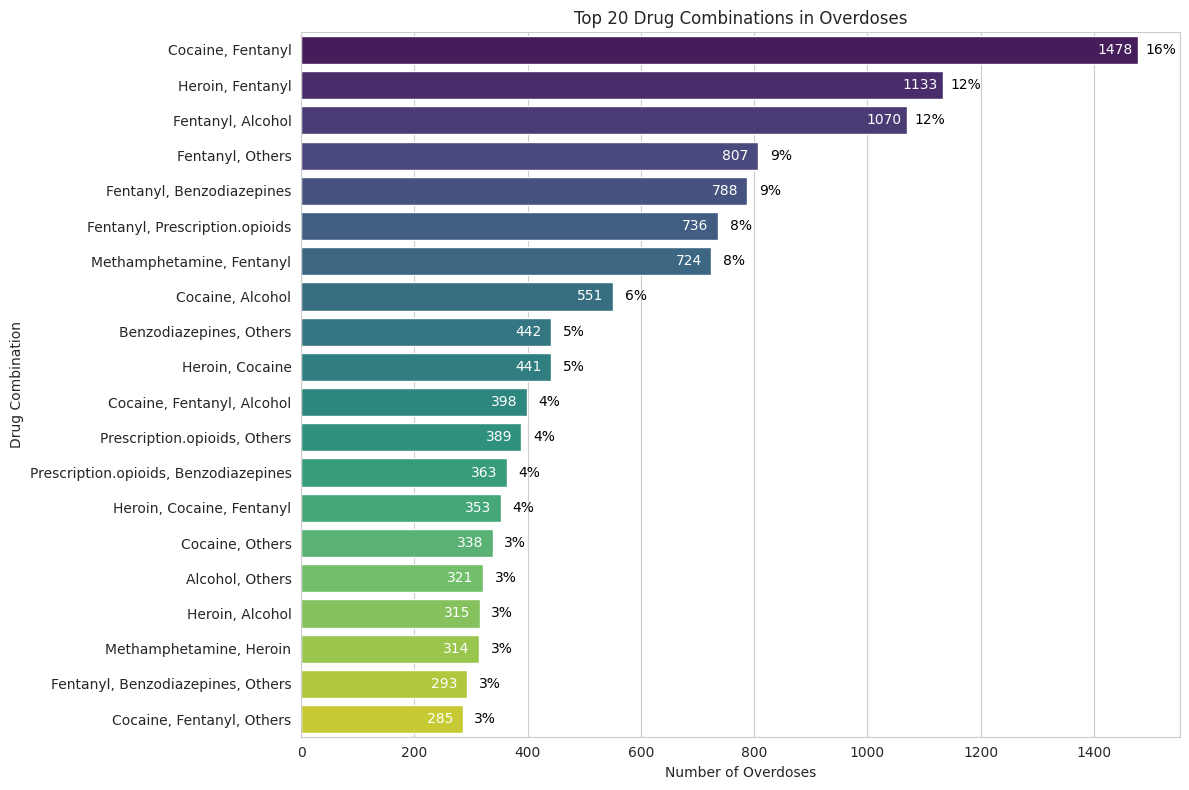

In [33]:
plot_top_drug_combinations_with_labels(top_co_occurrences)

In [ ]:
drug_df["Others"].value_counts()